# Lesson 3 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/3/3-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
to return. Replace `raise NotImplementedError` with your implementation;
the cell after it asserts the behaviour.

**A failing assert is information, not a grade.**

The written questions are marked and they carry the real learning
objective. Every one asks you to **run something both ways and explain
the difference** using numbers you produced. For each hyperparameter you
are asked about, say explicitly **which direction is underfitting, which
is overfitting, and what the metric does at each extreme**.

Every function you need is demonstrated in `3-practice.ipynb`, and each
task names the section.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`3-homework-results.ipynb`, and commit it to your fork under
`practice/3/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| scikit-learn", sklearn.__version__)

python 3.13.15 | scikit-learn 1.6.1


In [2]:
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
iris = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


In [3]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
# from sklearn.model_selection import (train_test_split, cross_val_score,
#                                      StratifiedKFold, KFold, GridSearchCV)
# from sklearn.pipeline import make_pipeline, Pipeline
# from sklearn.preprocessing import StandardScaler, PolynomialFeatures
# from sklearn.linear_model import LinearRegression, LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC
# from sklearn.cluster import KMeans
# from sklearn.mixture import GaussianMixture
# from sklearn.dummy import DummyClassifier
# from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
#                              silhouette_score, adjusted_rand_score)

#titanic = pd.read_csv("../datasets/titanic.csv")
#wine = pd.read_csv("../datasets/wine.csv")
#iris = pd.read_csv("../datasets/iris.csv")
#bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

#print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

## 2. Task 1 — Regression metrics from their definitions

Mechanical. Do not call scikit-learn's metric functions; build them from
the errors.

*see Practice 3 §4.2*

In [5]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    errors = y_true - y_pred

    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(errors))

    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - ss_res / ss_tot

    return {
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2)
    }

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
_guess = np.array([12.0, 18.0, 33.0, 39.0, 54.0])
_m = regression_metrics(_truth, _guess)

assert set(_m) == {"mse", "rmse", "mae", "r2"}
assert np.isclose(_m["mse"], mean_squared_error(_truth, _guess)), f"mse wrong: {_m['mse']}"
assert np.isclose(_m["rmse"], np.sqrt(mean_squared_error(_truth, _guess)))
assert np.isclose(_m["mae"], mean_absolute_error(_truth, _guess)), f"mae wrong: {_m['mae']}"
assert np.isclose(_m["r2"], r2_score(_truth, _guess)), f"r2 wrong: {_m['r2']}"

# A perfect prediction: zero error, R^2 exactly 1.
_perfect = regression_metrics(_truth, _truth)
assert np.isclose(_perfect["mse"], 0.0) and np.isclose(_perfect["r2"], 1.0)

# Predicting the mean every time gives R^2 of exactly 0, by construction.
_mean_only = regression_metrics(_truth, np.full_like(_truth, _truth.mean()))
assert np.isclose(_mean_only["r2"], 0.0), \
    f"always predicting the mean must give R^2 = 0, you got {_mean_only['r2']}"

# RMSE >= MAE always, with equality only when every error has the same size.
_noisy = rng.normal(0, 5, 500)
_m2 = regression_metrics(_noisy, np.zeros(500))
assert _m2["rmse"] >= _m2["mae"]

print({k: round(v, 4) for k, v in _m.items()})
print("Task 1 passed.")

{'mse': 6.8, 'rmse': 2.6077, 'mae': 2.4, 'r2': 0.966}
Task 1 passed.


### Question 1 — reading the metrics

Fit a `LinearRegression` to the bicycle data using `temp`, `hum` and
`windspeed` to predict `cnt`, on a 75/25 split with `random_state=SEED`.
Report all four metrics on the test set with your `regression_metrics`.

**(a)** Explain what RMSE means **in bicycles** for this model. Then
explain why the MSE figure cannot be interpreted the same way.

**(b)** Compute the ratio RMSE / MAE. What does a ratio well above 1 tell
you about the distribution of the errors? Find the ten worst-predicted
hours and say what they have in common.

**(c)** Your R² is low. Add the one-hot encoded `hr` column and refit.
How much does R² improve? Explain, referring to Practice 2 §8.4, why hour
of day carries so much of the signal and why it had to be one-hot encoded
rather than used as an integer.

In [7]:
X = bikes[["temp", "hum", "windspeed"]]
y = bikes["cnt"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=SEED )
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
metrics = regression_metrics(y_test, y_pred)
print("Features: temp, hum, windspeed")
print(pd.Series(metrics))
# (a) RMSE
print( f"rmse = {metrics['rmse']:.4f} bikes" )
# (b) RMSE / MAE
ratio = metrics["rmse"] / metrics["mae"]
print(f"MAE = {metrics["mae"]:.4f}")
print(f"RMSE / MAE = {ratio:.4f}")
results = X_test.copy()
results["actual_cnt"] = y_test
results["predicted_cnt"] = y_pred
results["error"] = results["actual_cnt"] - results["predicted_cnt"]
results["abs_error"] = abs(results["error"])


results = results.join( bikes.loc[X_test.index, ["hr", "dteday", "season", "weathersit", "yr","holiday","weekday","casual","registered"]] )
worst_10 = results.sort_values( "abs_error", ascending=False ).head(10)
print("\n=== TEN WORST-PREDICTED HOURS ===")
print( worst_10[ ["hr", "dteday", "season",  "weathersit", "yr","holiday","weekday","casual","registered","hum","windspeed"] ].to_string(index=False) )
X_base = bikes[["temp", "hum", "windspeed"]].copy()
# One-hot encoding for hr
hr_encoded = pd.get_dummies( bikes["hr"], prefix="hr", dtype=int )

X_full = pd.concat( [ X_base, hr_encoded ], axis=1 )
X_train_full = X_full.loc[X_train.index]
X_test_full = X_full.loc[X_test.index]
model_hr = LinearRegression()
model_hr.fit( X_train_full, y_train )
y_pred_hr = model_hr.predict( X_test_full )
metrics_hr = regression_metrics( y_test, y_pred_hr )
print("\n=== MODEL WITH ONE-HOT ENCODED hr ===")
print( pd.Series(metrics_hr) )


r2_base = metrics["r2"]
r2_hr = metrics_hr["r2"]
r2_improvement = r2_hr - r2_base
print("\n=== R² IMPROVEMENT ===")
print(f"Base R² = {r2_base:.4f}")
print(f"R² with hr = {r2_hr:.4f}")
print(f"Improvement = {r2_improvement:.4f}")
print( f"Improvement % = {r2_improvement / abs(r2_base) * 100:.2f}%" )
comparison = pd.DataFrame( { "Base": metrics, "With one-hot hr": metrics_hr } )
print("\n=== METRICS COMPARISON ===")
print(comparison)

Features: temp, hum, windspeed
mse    25,094.1254
rmse      158.4113
mae       118.9047
r2          0.2511
dtype: float64
rmse = 158.4113 bikes
MAE = 118.9047
RMSE / MAE = 1.3323

=== TEN WORST-PREDICTED HOURS ===
 hr     dteday  season  weathersit  yr  holiday  weekday  casual  registered    hum  windspeed
 17 2012-09-27       4           2   1        0        4      87         818 0.6900     0.2985
 17 2012-10-03       4           1   1        0        3      84         833 0.6500     0.0000
  8 2012-10-24       4           2   1        0        3      24         777 0.8300     0.1045
  8 2012-09-26       4           1   1        0        3      30         808 0.7300     0.2985
  8 2012-10-03       4           2   1        0        3      28         781 0.8800     0.1045
 17 2012-10-23       4           1   1        0        2      67         871 0.4100     0.0000
  8 2012-04-20       2           1   1        0        5      32         668 0.9400     0.0000
 17 2012-08-20       3    

**Your answer:**

а)RMSE показує типову величину помилки прогнозу в одиницях кількості орендованих велосипедів. MSE вимірюється у квадраті одиниць cnt, тобто в bikes², тому його не можна інтерпретувати як кількість велосипедів.


б) Дані параметри об'єднує, що це робочі дні з часами робочого перевезення 8-ма та 17 години.

c)Після додавання hr R² суттєво покращується, тому що година доби має сильний зв’язок із кількістю орендованих велосипедів. Попит сильно змінюється протягом дня: є години пік і години з низьким попитом.
Ми використовуємо one-hot encoding для hr, тому що це категоріальна ознака, а не звичайне числове значення. Якщо залишити hr як число, модель буде сприймати різницю між годинами як лінійну та однакову за змістом. One-hot encoding дозволяє кожній годині мати свій окремий ефект.

## 3. Task 2 — Classification metrics from the confusion matrix

Mechanical. Again, build them by hand.

*see Practice 3 §9.2 and §9.3*

In [8]:
def binary_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))

    # Precision = TP / (TP + FP)
    if tp + fp == 0:
        precision = 0.0
    else:
        precision = tp / (tp + fp)

    # Recall = TP / (TP + FN)
    if tp + fn == 0:
        recall = 0.0
    else:
        recall = tp / (tp + fn)

    # F1 = harmonic mean of precision and recall
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    }

In [9]:
_y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
_y_pred = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
_b = binary_metrics(_y_true, _y_pred)

assert set(_b) == {"tn", "fp", "fn", "tp", "precision", "recall", "f1"}
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (3, 1, 3, 3), \
    f"counts wrong: TN={_b['tn']} FP={_b['fp']} FN={_b['fn']} TP={_b['tp']}"
assert np.isclose(_b["precision"], 3 / 4)
assert np.isclose(_b["recall"], 3 / 6)
assert np.isclose(_b["f1"], 2 * 0.75 * 0.5 / 1.25)

# Must agree with sklearn's confusion_matrix, which orders cells the same way.
_sk_tn, _sk_fp, _sk_fn, _sk_tp = confusion_matrix(_y_true, _y_pred).ravel()
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (_sk_tn, _sk_fp, _sk_fn, _sk_tp)

# A model that never predicts the positive class: recall 0, no division error.
_never = binary_metrics(_y_true, np.zeros(10, dtype=int))
assert _never["recall"] == 0.0 and _never["precision"] == 0.0 and _never["f1"] == 0.0

print(_b)
print("Task 2 passed.")

{'tn': 3, 'fp': 1, 'fn': 3, 'tp': 3, 'precision': 0.75, 'recall': 0.5, 'f1': 0.6}
Task 2 passed.


## 4. Task 3 — The baseline you must state first

Mechanical.

*see Practice 3 §9.4*

In [10]:
def baseline_and_model(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    values, counts = np.unique(y_true, return_counts=True)
    majority_class = int(values[np.argmax(counts)])

    baseline_accuracy = np.mean(y_true == majority_class)

    model_accuracy = np.mean(y_true == y_pred)

    improvement = model_accuracy - baseline_accuracy

    return {
        "majority_class": majority_class,
        "baseline_accuracy": float(baseline_accuracy),
        "model_accuracy": float(model_accuracy),
        "improvement": float(improvement)
    }

In [11]:
_imbalanced = np.array([0] * 95 + [1] * 5)
_always_zero = np.zeros(100, dtype=int)
_r = baseline_and_model(_imbalanced, _always_zero)

assert _r["majority_class"] == 0
assert np.isclose(_r["baseline_accuracy"], 0.95)
assert np.isclose(_r["model_accuracy"], 0.95)
assert np.isclose(_r["improvement"], 0.0), \
    "a model that only predicts the majority class improves on the baseline by exactly 0"

_titanic_r = baseline_and_model(titanic["Survived"].values, np.zeros(len(titanic), dtype=int))
assert _titanic_r["majority_class"] == 0
assert np.isclose(_titanic_r["baseline_accuracy"], 0.6162, atol=1e-3), \
    f"Titanic's majority-class baseline is 0.6162, you got {_titanic_r['baseline_accuracy']}"

print(f"On a 95/5 split, a model with 95% accuracy has improved by "
      f"{_r['improvement']:.4f} over doing nothing.")
print("Task 3 passed.")

On a 95/5 split, a model with 95% accuracy has improved by 0.0000 over doing nothing.
Task 3 passed.


## 5. Task 4 — A leak-free pipeline

Applied. The scaler must be re-fitted inside every fold.

*see Practice 3 §6.3*

In [12]:
def compare_leak(X, y, cv):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    leaky_svc = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=SEED
    )

    leaky_scores = cross_val_score(
        leaky_svc,
        X_scaled,
        y,
        cv=cv,
        scoring="accuracy"
    )

    leaky = float(np.mean(leaky_scores))

    # Clean approach:
    # scaler is fitted separately inside each CV fold
    clean_estimator = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=SEED
        ))
    ])

    clean_scores = cross_val_score(
        clean_estimator,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    clean = float(np.mean(clean_scores))

    return {
        "leaky": leaky,
        "clean": clean,
        "difference": leaky - clean,
        "clean_estimator": clean_estimator
    }

In [13]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_leak = compare_leak(_X_wine, _y_wine, _cv)

assert set(_leak) == {"leaky", "clean", "difference", "clean_estimator"}
assert 0.9 < _leak["clean"] < 1.0, f"the clean score looks wrong: {_leak['clean']}"
assert np.isclose(_leak["difference"], _leak["leaky"] - _leak["clean"])

# The clean path must go through a Pipeline: that is the whole point, and it
# is checkable directly rather than through the score.
_estimator = _leak["clean_estimator"]
assert isinstance(_estimator, Pipeline), \
    f"the clean path must use a Pipeline, you passed a {type(_estimator).__name__}"
_step_types = [type(step).__name__ for _, step in _estimator.steps]
assert _step_types == ["StandardScaler", "SVC"], \
    f"expected StandardScaler then SVC, got {_step_types}"
# cross_val_score clones its estimator, so the object you passed in should
# still be unfitted. A fitted SVC carries a support_ attribute (Practice 3
# section 2: a trailing underscore means fit set it).
assert not hasattr(_estimator.named_steps["svc"], "support_"), \
    "return the estimator you passed to cross_val_score, not one you fitted yourself"

print(f"wine  leaky {_leak['leaky']:.4f}  clean {_leak['clean']:.4f}  "
      f"difference {_leak['difference']:+.4f}")
print("The two agree to four decimals here. Question 2(c) asks why, and when they would not.")
print("Task 4 passed.")

wine  leaky 0.9833  clean 0.9833  difference +0.0000
The two agree to four decimals here. Question 2(c) asks why, and when they would not.
Task 4 passed.


### Question 2 — folds and leakage

**(a)** Re-run `compare_leak` on the wine data with `cv` set to
`StratifiedKFold(k)` for k = 2, 5, 10 and `len(y)` (leave-one-out).
Tabulate the clean score and the leak at each. **Which direction does the
number of folds push the leak, and why?** Think about how much of the
data each fold's scaler sees.

**(b)** More folds means each model trains on more data and you fit more
models. State the trade-off in terms of bias, variance of the estimate,
and compute cost. Why is 5 or 10 the usual choice rather than
leave-one-out?

**(c)** Practice 3 §6.3 showed the leak reaching 27 percentage points with
a feature selector on pure noise, and essentially zero with a scaler on
wine. State the general rule that predicts which case you are in.

In [14]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values

for k in [2, 5, 10]:
    cv = StratifiedKFold(k, shuffle=True, random_state=SEED)
    result = compare_leak(_X_wine, _y_wine, cv)

    print(
        f"k={k:3d}  "
        f"clean={result['clean']:.4f}  "
        f"leaky={result['leaky']:.4f}  "
        f"difference={result['difference']:+.4f}"
    )


k=  2  clean=0.9775  leaky=0.9719  difference=-0.0056
k=  5  clean=0.9833  leaky=0.9833  difference=+0.0000
k= 10  clean=0.9833  leaky=0.9833  difference=+0.0000


**Your answer:**

а) Очікуваний напрямок: зі збільшенням кількості витік даних зазвичай зменшується.

б) Чим більше folds, тим більше даних використовується для навчання моделі, тому bias зменшується. Але оцінка може стати більш мінливою (variance зростає), а обчислення займають більше часу, бо потрібно навчити більше моделей.

Тому зазвичай використовують 5 або 10 folds — це хороший компроміс між точністю оцінки та швидкістю.

Leave-one-out вимагає навчити модель стільки разів, скільки є об'єктів у dataset, тому він значно дорожчий за часом.
с) Витік даних виникає, коли модель використовує інформацію з перевірочних даних під час навчання.

Якщо обробка даних майже не залежить від перевірочних даних → витік буде маленьким (як у випадку масштабування ознак на наборі Wine).
Якщо обробка даних використовує правильні відповіді для вибору ознак → витік може бути великим (як у випадку вибору ознак на випадковому шумі).

Головне правило: усі етапи обробки даних потрібно виконувати тільки на навчальних даних.

## 6. Task 5 — The bias-variance curve

Applied.

*see Practice 3 §7.3*

In [15]:
def degree_sweep(x, y, degrees, cv):
    """Fit a polynomial regression at each degree and record both errors.

    For each degree d in `degrees`, build
    make_pipeline(PolynomialFeatures(degree=d), LinearRegression()).

        train_mse  fit on ALL of (x, y), then the MSE of its predictions
                   on that same data
        cv_mse     the mean of -cross_val_score(..., cv=cv,
                   scoring='neg_mean_squared_error')

    `x` is 1-D; reshape it for scikit-learn (Practice 1 §3.5).

    Return a DataFrame indexed by degree with columns 'train_mse' and
    'cv_mse', in that order.
    """
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y)

    results = []

    for d in degrees:
        model = make_pipeline(
            PolynomialFeatures(degree=d),
            LinearRegression()
        )

        # Train MSE: fit on all data, then predict on the same data
        model.fit(x, y)
        y_pred = model.predict(x)

        train_mse = np.mean((y - y_pred) ** 2)

        # Cross-validation MSE
        cv_scores = cross_val_score(
            model,
            x,
            y,
            cv=cv,
            scoring="neg_mean_squared_error"
        )

        cv_mse = np.mean(-cv_scores)

        results.append({
            "degree": d,
            "train_mse": train_mse,
            "cv_mse": cv_mse
        })

    result = pd.DataFrame(results)
    result = result.set_index("degree")

    return result[["train_mse", "cv_mse"]]

In [16]:
_poly_rng = np.random.default_rng(SEED)
_x_poly = _poly_rng.uniform(-3, 3, 50)
_y_poly = (_x_poly ** 4 - 3 * _x_poly ** 2 + _x_poly + 5) + _poly_rng.normal(0, 12.0, 50)

_sweep = degree_sweep(_x_poly, _y_poly, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

assert list(_sweep.columns) == ["train_mse", "cv_mse"]
assert len(_sweep) == 15

# Training error must fall (weakly) as the model gains flexibility.
_train = _sweep["train_mse"].values
assert np.all(np.diff(_train) < 1e-6), \
    "training MSE must be non-increasing in the degree; a degree-d model can do anything a degree-(d-1) model can"

# Validation error must NOT be monotone: it has a minimum and then rises.
assert _sweep["cv_mse"].idxmin() < 15, "validation error should not be minimised at the highest degree"
assert _sweep.loc[15, "cv_mse"] > _sweep["cv_mse"].min() * 10, \
    "a degree-15 polynomial on 50 noisy points should overfit badly"
assert _sweep.loc[1, "cv_mse"] > _sweep["cv_mse"].min() * 2, \
    "a straight line should underfit a quartic badly"

print(_sweep.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep['cv_mse'].idxmin()}")
print("Task 5 passed.")

        train_mse      cv_mse
degree                       
1        397.8800    468.4700
2        146.8600    165.9000
3        144.4100    168.8300
4         82.1600    111.8500
5         81.3900    120.0800
6         81.1400    128.5300
7         81.0700    157.3500
8         73.3200    113.4500
9         70.4200    115.2500
10        69.2800    118.8700
11        68.6700    171.4900
12        68.4400  1,699.0900
13        68.4400 19,405.7200
14        66.2600 91,266.7500
15        65.9500 28,992.7500

best degree by cross-validation: 4
Task 5 passed.


### Question 3 — polynomial degree

Plot both columns of your sweep on one axes with a log y scale.

**(a)** Identify the underfitting region and the overfitting region by
degree. For each, say what the **training** error is doing and what the
**validation** error is doing, and explain why the gap between them is
the diagnostic rather than either curve alone.

**(b)** At the extremes: what does training MSE tend to as the degree
approaches the number of data points, and why? What does validation MSE
do?

**(c)** Re-run the sweep with 500 points instead of 50, same noise. Which
degree wins now, and how far does the overfitting region move? State the
general relationship between the amount of data and the model complexity
you can afford.

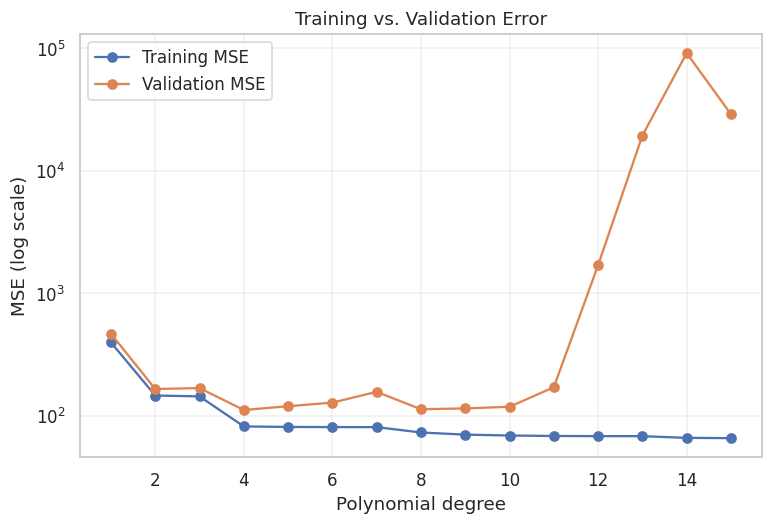

        train_mse   cv_mse
degree                    
1        339.2000 341.5000
2        176.1400 178.2000
3        176.1300 179.7500
4        137.2900 140.5000
5        136.8800 140.6700
6        136.5100 141.0200
7        136.2600 141.2000
8        136.1500 143.0700
9        136.0600 143.1600
10       135.6100 143.7200
11       135.4800 144.7600
12       135.4600 148.3100
13       135.4100 158.6400
14       135.4100 184.2100
15       134.8000 168.0900

best degree by cross-validation: 4


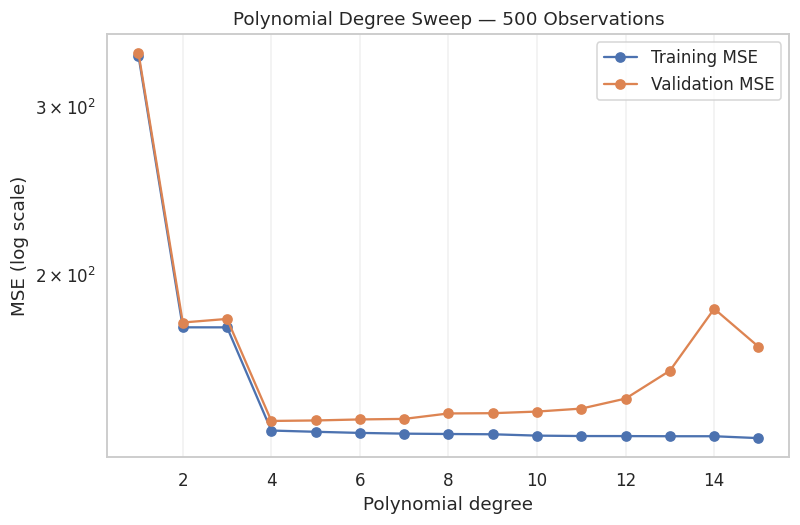

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(_sweep.index, _sweep["train_mse"], marker="o", label="Training MSE")
plt.plot(_sweep.index, _sweep["cv_mse"], marker="o", label="Validation MSE")

plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE (log scale)")
plt.title("Training vs. Validation Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

_poly_rng_500 = np.random.default_rng(SEED)

_x_poly_500 = _poly_rng_500.uniform(-3, 3, 500)
_y_poly_500 = (
    _x_poly_500 ** 4
    - 3 * _x_poly_500 ** 2
    + _x_poly_500
    + 5
    + _poly_rng_500.normal(0, 12.0, 500)
)

_sweep_500 = degree_sweep(
    _x_poly_500,
    _y_poly_500,
    range(1, 16),
    KFold(5, shuffle=True, random_state=SEED)
)

print(_sweep_500.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep_500['cv_mse'].idxmin()}")

plt.figure(figsize=(8, 5))
plt.plot(_sweep_500.index, _sweep_500["train_mse"],
         marker="o", label="Training MSE")
plt.plot(_sweep_500.index, _sweep_500["cv_mse"],
         marker="o", label="Validation MSE")
plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE (log scale)")
plt.title("Polynomial Degree Sweep — 500 Observations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Your answer:**

а) Область недостатності 0-4, Після 10 очинається перенавчання. Навчальна помилка продовжує зменшуватися, але валідаційна помилка починає зростати.

На малих ступенях полінома модель недонавчається. Навчальна та валідаційна помилки досить великі. Коли ступінь збільшується, навчальна помилка зменшується, і валідаційна помилка теж спочатку зменшується.

б) Коли ступінь полінома наближається до кількості точок, training MSE наближається до нуля.
Причина в тому, що дуже складна модель може майже ідеально пройти через усі навчальні точки, включно з шумом.
Але validation MSE при цьому сильно зростає, тому що модель перенавчається і погано працює на нових даних.

в) Якщо збільшити кількість даних з 50 до 500, модель може дозволити собі більший ступінь полінома.

Тобто область перенавчання зміститься до більших ступенів.

Загальне правило таке: чим більше даних, тим складнішу модель можна використовувати без сильного перенавчання.

## 7. Task 6 — Tune a tree honestly

Applied.

*see Practice 3 §8.3 and §6.4*

In [35]:
def tune_tree(X, y, cv, depths=(1, 2, 3, 4, 5, 6, 8, 10, None), criteria=("gini", "entropy")):
    """Grid-search a DecisionTreeClassifier over max_depth and criterion.

    Use GridSearchCV with the given `cv`, scoring='accuracy', refit=True,
    and DecisionTreeClassifier(random_state=SEED).

    Return a dict with exactly these four keys:
        'best_depth'      the chosen max_depth (may be None)
        'best_criterion'  the chosen criterion, a string
        'best_cv_score'   the best cross-validated accuracy, a float
        'search'          the fitted GridSearchCV object
    """
    if depths is None:
        depths = [1, 2, 3, 4, 5, 6, 7, 8, 9]

    if criteria is None:
        criteria = ["gini", "entropy"]

    model = DecisionTreeClassifier(random_state=SEED)

    param_grid = {
        "max_depth": depths,
        "criterion": criteria
    }

    search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        refit=True
    )

    search.fit(X, y)

    return {
        "best_depth": search.best_params_["max_depth"],
        "best_criterion": search.best_params_["criterion"],
        "best_cv_score": float(search.best_score_),
        "search": search
    }

In [37]:
_X_iris = iris.drop(columns=["Id", "Species"]).values
_y_iris = iris["Species"].values
_iris_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_tuned = tune_tree(_X_iris, _y_iris, _iris_cv)

assert set(_tuned) == {"best_depth", "best_criterion", "best_cv_score", "search"}
assert _tuned["best_criterion"] in ("gini", "entropy")
assert 0.9 < _tuned["best_cv_score"] <= 1.0, f"CV score looks wrong: {_tuned['best_cv_score']}"
assert len(_tuned["search"].cv_results_["params"]) == 18, \
    "9 depths x 2 criteria = 18 combinations"

# A depth-1 tree cannot separate three classes: it has only two leaves.
_depth1 = cross_val_score(DecisionTreeClassifier(max_depth=1, random_state=SEED),
                          _X_iris, _y_iris, cv=_iris_cv).mean()
assert _depth1 < 0.75, f"a two-leaf tree should not classify three classes well, got {_depth1:.4f}"
assert _tuned["best_cv_score"] > _depth1, "tuning should beat the depth-1 stump"

# The chosen tree must not be the fully grown one if a shallower one ties it.
_full = cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean()
print(f"best: max_depth={_tuned['best_depth']}, criterion={_tuned['best_criterion']}, "
      f"CV {_tuned['best_cv_score']:.4f}")
print(f"depth-1 stump CV {_depth1:.4f}   fully grown tree CV {_full:.4f}")
print("Task 6 passed.")

best: max_depth=4, criterion=gini, CV 0.9333
depth-1 stump CV 0.6667   fully grown tree CV 0.9333
Task 6 passed.


### Question 4 — tree hyperparameters

**(a)** Using `_tuned['search'].cv_results_`, tabulate the CV score at
every `max_depth` for both criteria. **Which direction is underfitting
and which is overfitting?** Give the depth at which each begins for this
data.

**(b)** `gini` and `criterion='entropy'` gave nearly the same answer.
Explain what each measures and why they rarely disagree. Construct or
describe a situation in which they might.

**(c)** Fit a tree with `max_depth=None` and report its **training**
accuracy. Explain in one sentence why that number is uninformative, and
name the other hyperparameter from Practice 3 §8.3 that limits the same
behaviour from a different direction.

param_max_depth param_criterion  mean_test_score
              1         entropy           0.6667
              2         entropy           0.9200
              3         entropy           0.9200
              4         entropy           0.9333
              5         entropy           0.9333
              6         entropy           0.9333
              8         entropy           0.9333
             10         entropy           0.9333
           None         entropy           0.9333
              1            gini           0.6667
              2            gini           0.9200
              3            gini           0.9200
              4            gini           0.9333
              5            gini           0.9333
              6            gini           0.9333
              8            gini           0.9333
             10            gini           0.9333
           None            gini           0.9333
Training accuracy: 1.0000

=== UNRESTRICTED TREE ===
Training accurac

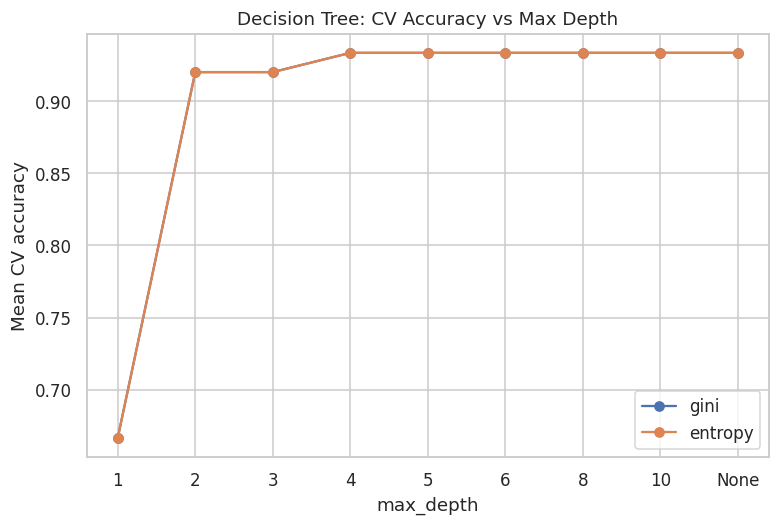

In [38]:
results = pd.DataFrame(_tuned["search"].cv_results_)

table = results[["param_max_depth", "param_criterion", "mean_test_score"]] \
    .sort_values(["param_criterion", "param_max_depth"])
results = pd.DataFrame(_tuned["search"].cv_results_)

print(table.to_string(index=False))

# Fit an unrestricted tree for part (c)
tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)

tree.fit(_X_iris, _y_iris)

train_accuracy = tree.score(_X_iris, _y_iris)

print(f"Training accuracy: {train_accuracy:.4f}")
tree_none = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)

tree_none = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)

tree_none.fit(_X_iris, _y_iris)

train_accuracy = tree_none.score(_X_iris, _y_iris)

print("\n=== UNRESTRICTED TREE ===")
print("Training accuracy:", round(train_accuracy, 4))


# Plot CV accuracy
cv_results = _tuned["search"].cv_results_
plot_results = pd.DataFrame(cv_results)

# Convert None to readable labels
plot_results["depth_label"] = plot_results["param_max_depth"].astype(str)

plt.figure(figsize=(8, 5))

for criterion in ["gini", "entropy"]:
    subset = plot_results[
        plot_results["param_criterion"] == criterion
    ]

    plt.plot(
        subset["depth_label"],
        subset["mean_test_score"],
        marker="o",
        label=criterion
    )

plt.xlabel("max_depth")
plt.ylabel("Mean CV accuracy")
plt.title("Decision Tree: CV Accuracy vs Max Depth")
plt.legend()
plt.grid(True)
plt.show()

**Your answer:**

а) При max_depth=1 дерево занадто просте, тому це недонавчання. Точність лише 0,6667. При max_depth=2 точність вже 0,9200, а при max_depth=4 — 0,9333.
Після 4 точність майже не змінюється. Тобто сильного перенавчання тут не видно.
Gini і Entropy дають майже однакові результати.

б) Gini і Entropy показують, наскільки добре класи розділені в дереві.
Обидва методи намагаються зробити групи якомога чистішими, тому зазвичай дають схожий результат.
Вони можуть відрізнятися, якщо різні розділення мають дуже близькі результати.

с) При max_depth=None точність на навчальних даних становить 1,0000, тобто 100%.
Це не дуже інформативно, тому що дерево могло просто запам'ятати навчальні дані.
Параметр min_samples_leaf також допомагає запобігти такому перенавчанню, задаючи мінімальну кількість даних у кожному листі.

## 8. Task 7 — Choose k without touching the test set

Applied. This is the procedure from Practice 3 §10.4, implemented.

*see Practice 3 §10.3 and §10.4*

In [24]:
def honest_k_selection(X_train, y_train, X_test, y_test, k_values, cv):
    """Choose k by cross-validation on the training set, then measure once.

    For each k in `k_values`, cross-validate
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    on the TRAINING data only, using `cv`.

    Choose the k with the highest mean CV accuracy (the smallest such k if
    several tie). Refit that pipeline on all the training data and score
    it once on the test set.

    Also record, for comparison, the k that would have been chosen by
    scoring each k directly on the TEST set, and that k's test score.

    Return a dict with exactly these five keys:
        'cv_scores'         a 1-D array of mean CV accuracy, one per k
        'best_k_cv'         the k chosen by cross-validation
        'test_accuracy'     the honest test accuracy of that k
        'best_k_peeking'    the k that maximises test accuracy
        'peeking_accuracy'  that k's test accuracy (an optimistic number)
    """
    cv_scores = []

    # Cross-validation ONLY on training data
    for k in k_values:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy"
        )

        cv_scores.append(np.mean(scores))

    cv_scores = np.asarray(cv_scores)

    # Highest CV accuracy; np.argmax returns the first one,
    # so the smallest k wins in case of a tie.
    best_index = np.argmax(cv_scores)
    best_k_cv = k_values[best_index]

    # Refit the selected model on ALL training data
    best_model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=best_k_cv)
    )

    best_model.fit(X_train, y_train)

    # Evaluate ONCE on the test set
    test_accuracy = best_model.score(X_test, y_test)

    # Peeking: choose k directly using the test set
    test_scores = []

    for k in k_values:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )

        model.fit(X_train, y_train)
        test_scores.append(model.score(X_test, y_test))

    test_scores = np.asarray(test_scores)

    best_peeking_index = np.argmax(test_scores)
    best_k_peeking = k_values[best_peeking_index]
    peeking_accuracy = test_scores[best_peeking_index]

    return {
        "cv_scores": cv_scores,
        "best_k_cv": best_k_cv,
        "test_accuracy": float(test_accuracy),
        "best_k_peeking": best_k_peeking,
        "peeking_accuracy": float(peeking_accuracy)
    }

In [25]:
_t = titanic.copy()
_t["Age"] = _t["Age"].fillna(_t.groupby(["Pclass", "Sex"])["Age"].transform("median"))
_t["Sex"] = (_t["Sex"] == "female").astype(int)
_X_knn = _t[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].values
_y_knn = _t["Survived"].values

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn, _y_knn, test_size=0.25, random_state=SEED, stratify=_y_knn
)
_k_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_sel = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 31), _k_cv)

assert set(_sel) == {"cv_scores", "best_k_cv", "test_accuracy",
                     "best_k_peeking", "peeking_accuracy"}
assert len(_sel["cv_scores"]) == 30
assert 1 <= _sel["best_k_cv"] <= 30

# The k chosen by CV must be the argmax OF THE CV SCORES, not of the test scores.
assert _sel["best_k_cv"] == list(range(1, 31))[int(np.argmax(_sel["cv_scores"]))], \
    "best_k_cv must maximise the cross-validated score, not the test score"

# Peeking at the test set can never look worse than the honest procedure:
# it is the maximum over the same set of numbers.
assert _sel["peeking_accuracy"] >= _sel["test_accuracy"] - 1e-12, \
    "selecting on the test set cannot produce a lower test score than any single choice"

print(f"k by cross-validation : {_sel['best_k_cv']:2}  ->  honest test accuracy "
      f"{_sel['test_accuracy']:.4f}")
print(f"k by peeking at test  : {_sel['best_k_peeking']:2}  ->  optimistic accuracy "
      f"{_sel['peeking_accuracy']:.4f}")
print(f"the optimism is {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print("Task 7 passed.")

k by cross-validation : 18  ->  honest test accuracy 0.8206
k by peeking at test  : 25  ->  optimistic accuracy 0.8520
the optimism is +0.0314
Task 7 passed.


### Question 5 — k, and the one-use rule

**(a)** Plot your `cv_scores` against k. **Which end is underfitting and
which is overfitting?** Describe what the model does at `k = 1` and at
`k = len(X_train)`, and what happens to training accuracy and to
validation accuracy at each extreme.

**(b)** Your two procedures reported different numbers. Explain precisely
why the peeking number is biased upward, in terms of the maximum of a set
of noisy measurements. Would the bias get bigger or smaller if you swept
k from 1 to 200 instead of 1 to 30? Test it.

**(c)** Vary `test_size` over 0.1, 0.25 and 0.4 with the same seed, and
report the honest test accuracy at each. Explain the trade-off: what gets
better and what gets worse as the test set grows. Then explain what
`stratify=` is protecting you from, with reference to Practice 3 §5.3.

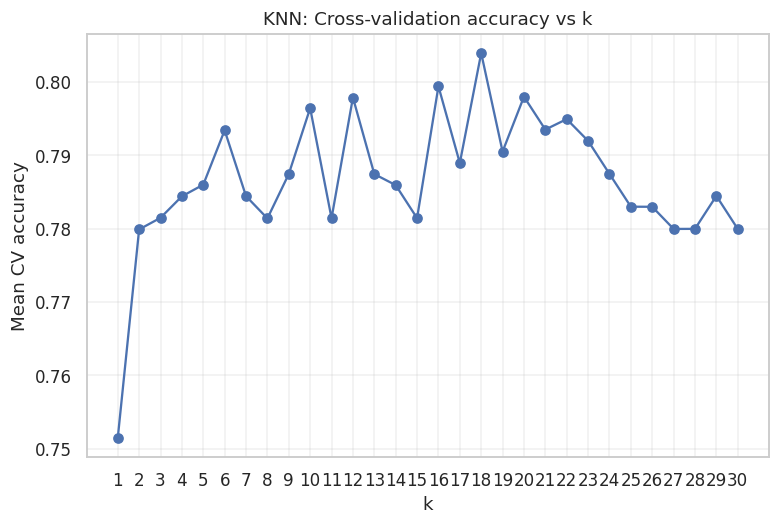

Best k by CV: 18
Best CV accuracy: 0.8039052856020648
k by CV      : 18
honest test  : 0.8206
k by peeking : 25
peeking test : 0.8520
optimism     : +0.0314
Sweep k = 1...200
k by CV      : 18
honest test  : 0.8206
k by peeking : 25
peeking test : 0.8520
optimism     : +0.0314
test_size=0.10 | train=801 | test= 90 | best k=18 | honest accuracy=0.8333
test_size=0.25 | train=668 | test=223 | best k=18 | honest accuracy=0.8206
test_size=0.40 | train=534 | test=357 | best k= 8 | honest accuracy=0.8095


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Plot CV accuracy against k
ks = np.arange(1, 31)

plt.figure(figsize=(8, 5))
plt.plot(ks, _sel["cv_scores"], marker="o")
plt.xlabel("k")
plt.ylabel("Mean CV accuracy")
plt.title("KNN: Cross-validation accuracy vs k")
plt.xticks(ks)
plt.grid(True, alpha=0.3)
plt.show()

# Print the best k
print("Best k by CV:", _sel["best_k_cv"])
print("Best CV accuracy:", _sel["cv_scores"][_sel["best_k_cv"] - 1])

#b)
print(f"k by CV      : {_sel['best_k_cv']}")
print(f"honest test  : {_sel['test_accuracy']:.4f}")

print(f"k by peeking : {_sel['best_k_peeking']}")
print(f"peeking test : {_sel['peeking_accuracy']:.4f}")

print(f"optimism     : "
      f"{_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
_sel_200 = honest_k_selection(
    _Xk_tr,
    _yk_tr,
    _Xk_te,
    _yk_te,
    range(1, 201),
    _k_cv
)

print("Sweep k = 1...200")
print(f"k by CV      : {_sel_200['best_k_cv']}")
print(f"honest test  : {_sel_200['test_accuracy']:.4f}")
print(f"k by peeking : {_sel_200['best_k_peeking']}")
print(f"peeking test : {_sel_200['peeking_accuracy']:.4f}")
print(f"optimism     : "
      f"{_sel_200['peeking_accuracy'] - _sel_200['test_accuracy']:+.4f}")
test_sizes = [0.1, 0.25, 0.4]

results = []

for test_size in test_sizes:
    X_tr, X_te, y_tr, y_te = train_test_split(
        _X_knn,
        _y_knn,
        test_size=test_size,
        random_state=SEED,
        stratify=_y_knn
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )

    result = honest_k_selection(
        X_tr,
        y_tr,
        X_te,
        y_te,
        range(1, 31),
        cv
    )

    results.append({
        "test_size": test_size,
        "train_size": len(X_tr),
        "test_n": len(X_te),
        "best_k_cv": result["best_k_cv"],
        "test_accuracy": result["test_accuracy"]
    })

for r in results:
    print(
        f"test_size={r['test_size']:.2f} | "
        f"train={r['train_size']:3} | "
        f"test={r['test_n']:3} | "
        f"best k={r['best_k_cv']:2} | "
        f"honest accuracy={r['test_accuracy']:.4f}"
    )


**Your answer:**

(a) На графіку видно, що при малому k модель більше схильна до overfitting, а при великому k — до underfitting.

При k = 1 модель дуже чутлива до окремих об'єктів і шуму. Training accuracy дуже висока, але validation accuracy може бути гіршою.

При дуже великому k модель стає занадто простою і більше орієнтується на загальний, найпоширеніший клас. Через це і training, і validation accuracy знижуються.

У моєму результаті найкраще k за cross-validation дорівнює 18, а середня CV accuracy становить 0.8039.

б) Cross-validation вибрала k = 18. Для нього чесна test accuracy становить 0.8206.
Якщо вибирати k, дивлячись на test set, отримуємо k = 25 і accuracy 0.8520.
Різниця:
0.8520 - 0.8206 = 0.0314
Тобто peeking завищив результат приблизно на 3.14%. При перевірці k = 1...200 результат не змінився: залишилися k = 25, accuracy 0.8520 і optimism 0.0314. Це означає, що додаткові значення k від 31 до 200 не дали кращого результату.

с) Коли test set збільшувався, training set ставав меншим. Accuracy у моєму експерименті зменшилася з 0.8333 до 0.8206, а потім до 0.8095.
При меншому test set більше даних використовується для навчання моделі. При більшому test set більше даних використовується для перевірки, але менше залишається для навчання.
stratify потрібен для того, щоб у training і test sets залишалася приблизно однакова пропорція класів Survived = 0 і Survived = 1. Це робить поділ даних більш справедливим і захищає від випадкового дисбалансу класів.

## 9. Task 8 — Recover an SVM boundary in original units

Applied. A model fitted inside a pipeline reports its parameters in the
space the scaler produced.

*see Practice 3 §11.4*

In [39]:
def boundary_in_original_units(pipeline):
    """Convert a fitted (StandardScaler -> linear SVC) pipeline's decision
    boundary from scaled space back to original coordinates.

    The pipeline has exactly two steps: 'standardscaler' and 'svc', and
    the SVC has kernel='linear' and was fitted on two features.

    In scaled space the boundary is  w1*z1 + w2*z2 + b = 0, with
    z1 = (x - mu_x)/s_x and z2 = (y - mu_y)/s_y.

    Solve for y and return a tuple (slope, intercept) such that
    y = slope * x + intercept is that same boundary in original units.

    Raise ValueError if w2 is zero (a vertical boundary has no such form).
    """
    scaler = pipeline.named_steps["standardscaler"]
    svc = pipeline.named_steps["svc"]

    w1, w2 = svc.coef_[0]
    b = svc.intercept_[0]

    mu_x, mu_y = scaler.mean_
    s_x, s_y = scaler.scale_

    if w2 == 0:
        raise ValueError("w2 is zero: the boundary is vertical")

    slope = -(w1 * s_y) / (w2 * s_x)

    intercept = (
        mu_y
        + (w1 * s_y / (w2 * s_x)) * mu_x
        - (b * s_y / w2)
    )

    return float(slope), float(intercept)

In [40]:
_svr_rng = np.random.default_rng(SEED)
_n = 300
_x_lines = _svr_rng.uniform(0, 5, _n)
_y1 = 1.0 * _x_lines + 3.0 + _svr_rng.normal(0, 1, _n)
_y2 = 2.0 * _x_lines + 5.0 + _svr_rng.normal(0, 1, _n)

_X_two = np.vstack([np.column_stack([_x_lines, _y1]), np.column_stack([_x_lines, _y2])])
_y_two = np.hstack([np.zeros(_n, dtype=int), np.ones(_n, dtype=int)])

_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
_pipe.fit(_X_two, _y_two)

_slope, _intercept = boundary_in_original_units(_pipe)

# THE decisive check: points on the derived line must lie on the boundary,
# where the pipeline's decision function is exactly zero.
_check_x = np.linspace(0.5, 4.5, 9)
_check_y = _slope * _check_x + _intercept
_decisions = _pipe.decision_function(np.column_stack([_check_x, _check_y]))
assert np.allclose(_decisions, 0.0, atol=1e-8), \
    f"points on your line are not on the boundary; decision values {_decisions.round(6)}"

# The boundary must lie between the two generating lines.
assert 1.0 < _slope < 2.0, f"slope {_slope:.4f} should be between the true slopes 1 and 2"

# Points clearly above and below must fall on opposite sides.
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept + 4]])[0] == 1
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept - 4]])[0] == 0

print(f"boundary in original units: y = {_slope:.4f} * x + {_intercept:.4f}")
print(f"decision function on the line: {np.abs(_decisions).max():.2e} (essentially zero)")
print("Task 8 passed.")

boundary in original units: y = 1.4168 * x + 4.1898
decision function on the line: 1.40e-14 (essentially zero)
Task 8 passed.


### Question 6 — C, gamma and the kernel

**(a)** Refit the two-line classifier with `C` = 0.001, 1, 1000. Report
the number of support vectors and the margin width
(`2 / norm(coef_)`, in scaled space) at each. **Which direction is
underfitting and which is overfitting?** What does `C` do to the margin
at each extreme?

**(b)** Now switch to `kernel='rbf'` and sweep `gamma` over 0.01, 1, 100
at fixed `C=1`, scoring by cross-validation. Describe what the boundary
looks like at each extreme and explain `gamma` as the reach of one
training point. Which extreme memorises?

**(c)** These data are linearly separable apart from noise. Does the RBF
kernel beat the linear one here? Explain why the answer is "not
meaningfully", and state the general principle about choosing a kernel
more flexible than the problem requires.

In [41]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
import numpy as np

for C in [0.001, 1, 1000]:
    pipe = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=C, random_state=SEED)
    )
    pipe.fit(_X_two, _y_two)

    svc = pipe.named_steps["svc"]
    n_sv = len(svc.support_)
    margin_width = 2 / np.linalg.norm(svc.coef_)

    print(
        f"C={C:<7} "
        f"support vectors={n_sv:<3} "
        f"margin width={margin_width:.4f}"
    )


for gamma in [0.01, 1, 100]:
    pipe = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=1, gamma=gamma, random_state=SEED)
    )

    scores = cross_val_score(
        pipe, _X_two, _y_two,
        cv=5,
        scoring="accuracy"
    )

    print(
        f"gamma={gamma:<5} "
        f"CV accuracy={scores.mean():.4f} "
        f"+/- {scores.std():.4f}"
    )

C=0.001   support vectors=600 margin width=4.9368
C=1       support vectors=74  margin width=0.4146
C=1000    support vectors=46  margin width=0.2189
gamma=0.01  CV accuracy=0.9617 +/- 0.0041
gamma=1     CV accuracy=0.9700 +/- 0.0041
gamma=100   CV accuracy=0.9550 +/- 0.0125


**Your answer:**

а) Для C=0.001 модель має 600 support vectors і широкий margin 4.9368, тому вона недопідганяє дані (underfitting). При C=1 маємо 74 support vectors і margin 0.4146, а при C=1000 — 46 support vectors і найвужчий margin 0.2189. Отже, малий C дає широкий margin і допускає більше помилок, а великий C робить margin вузьким і може призвести до overfitting.

б) Для RBF найвища cross-validation accuracy отримана при gamma=1 — 0.9700. При gamma=0.01 boundary дуже гладка, оскільки кожна точка має великий радіус впливу. При gamma=100 вплив точок стає дуже локальним, boundary стає звивистою, що може призвести до memorisation/overfitting; це видно і за нижчою accuracy 0.9550.

с) RBF тут не дає суттєвої переваги над linear kernel, оскільки дані переважно лінійно розділяються. Загальний принцип: не варто використовувати складніше ядро, ніж вимагає структура задачі, оскільки зайва гнучкість може спричинити overfitting.

## 10. Task 9 — Choosing the number of clusters

Applied.

*see Practice 3 §13.3 and §14.5*

In [45]:
def cluster_selection(X, k_values):
    """Score k-means and a Gaussian mixture across several k.

    For each k in `k_values` (all >= 2), compute four numbers:
        'inertia'      KMeans(n_clusters=k, n_init=10, random_state=SEED).inertia_
        'silhouette'   silhouette_score of that KMeans labelling
        'bic'          GaussianMixture(n_components=k, covariance_type='full',
                       random_state=SEED).bic(X)
        'aic'          the same model's aic(X)

    Return a DataFrame indexed by k with those four columns, in that order.
    """
    results = []

    for k in k_values:
        # K-Means
        kmeans = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=SEED
        )
        labels = kmeans.fit_predict(X)

        inertia = kmeans.inertia_
        silhouette = silhouette_score(X, labels)

        # Gaussian Mixture
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=SEED
        )
        gmm.fit(X)

        bic = gmm.bic(X)
        aic = gmm.aic(X)

        results.append({
            "k": k,
            "inertia": inertia,
            "silhouette": silhouette,
            "bic": bic,
            "aic": aic
        })

    result = pd.DataFrame(results).set_index("k")

    return result[["inertia", "silhouette", "bic", "aic"]]

In [46]:
_blob_rng = np.random.default_rng(SEED)
_centres = np.array([[-4.0, -2.0], [0.0, 3.5], [4.0, -1.0], [6.5, 4.0]])
_X_blobs = np.vstack([_blob_rng.multivariate_normal(c, np.eye(2), 75) for c in _centres])

_scores = cluster_selection(_X_blobs, range(2, 8))

assert list(_scores.columns) == ["inertia", "silhouette", "bic", "aic"]
assert len(_scores) == 6

# Inertia falls monotonically: more clusters always fit the points more tightly.
assert np.all(np.diff(_scores["inertia"].values) < 0), \
    "inertia must decrease as k increases, which is why it cannot be minimised to choose k"

# On four well-separated round blobs, every criterion should find four.
assert _scores["silhouette"].idxmax() == 4, \
    f"silhouette chose {_scores['silhouette'].idxmax()}, expected 4 on four round blobs"
assert _scores["bic"].idxmin() == 4, f"BIC chose {_scores['bic'].idxmin()}, expected 4"

print(_scores.round(3).to_string())
print(f"\nsilhouette -> {_scores['silhouette'].idxmax()},  "
      f"BIC -> {_scores['bic'].idxmin()},  AIC -> {_scores['aic'].idxmin()}")
print("Task 9 passed.")

     inertia  silhouette        bic        aic
k                                             
2 3,260.9450      0.4940 2,842.1730 2,801.4310
3 1,694.5460      0.5650 2,716.3210 2,653.3560
4   553.3610      0.6970 2,603.9330 2,518.7460
5   495.1520      0.5980 2,631.5810 2,524.1720
6   443.6920      0.5070 2,664.4790 2,534.8470
7   387.6340      0.4260 2,691.7670 2,539.9120

silhouette -> 4,  BIC -> 4,  AIC -> 4
Task 9 passed.


### Question 7 — clustering choices

**(a)** Plot inertia against k. Explain why it cannot be minimised to
choose k, and what the "elbow" is supposed to represent. Then state
honestly how confident you are reading the elbow on your own plot.

**(b)** Now build the harder data below — three tilted components, two of
which overlap — and run `cluster_selection` on it. **Silhouette and BIC
will disagree.** Report both answers, say which is right, and explain
*why* the silhouette gives the answer it does in terms of what it
measures.

**(c)** Re-run k-means on that data with `n_init=1` and ten different
`random_state` values, recording the inertia each time. Report the spread.
What is `n_init` for, and what does `init='k-means++'` change?

**(d)** Fit a GMM to that data with each `covariance_type` in
`('full', 'tied', 'diag', 'spherical')` and report the adjusted Rand
index against the true labels. Which assumption is each making, and which
one reproduces k-means' behaviour?

In [44]:
# The harder data for parts (b), (c) and (d). Do not modify this cell.
_hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack([
    _hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    _hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    _hard_rng.multivariate_normal([6.0, 6.5], [[3.0, 1.5], [1.5, 2.0]], 300),
])
y_hard = np.repeat([0, 1, 2], 300)

print("X_hard", X_hard.shape, " true components: 3")

X_hard (900, 2)  true components: 3


      inertia  silhouette        bic        aic
k                                              
2  7,175.0015      0.5161 8,512.4188 8,459.5924
3  4,690.2507      0.4231 8,410.6689 8,329.0282
4  3,470.1581      0.4282 8,451.9986 8,341.5436
5  2,822.5206      0.4039 8,490.5456 8,351.2761
6  2,355.3401      0.3660 8,526.4194 8,358.3356
7  1,994.2769      0.3680 8,559.2666 8,362.3684
8  1,798.1532      0.3576 8,589.0598 8,363.3472
9  1,621.2559      0.3443 8,626.9645 8,372.4375
10 1,472.8757      0.3411 8,660.2061 8,376.8648


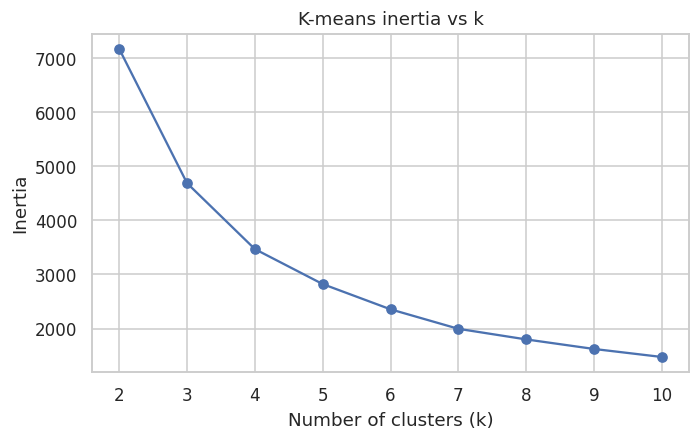

Inertia values:

Scores on X_hard:
     inertia  silhouette        bic        aic
k                                             
2 7,175.0020      0.5160 8,512.4190 8,459.5920
3 4,690.2510      0.4230 8,410.6690 8,329.0280
4 3,470.1580      0.4280 8,451.9990 8,341.5440
5 2,822.5210      0.4040 8,490.5460 8,351.2760
6 2,355.3400      0.3660 8,526.4190 8,358.3360
7 1,994.2770      0.3680 8,559.2670 8,362.3680

Silhouette -> k=2
BIC        -> k=3

K-Means with n_init=1:
 random_state    inertia
            0 4,691.9290
            1 4,690.2510
            2 4,690.2510
            3 4,691.9290
            4 4,691.9290
            5 4,691.9290
            6 4,691.9290
            7 4,692.7430
            8 4,691.9290
            9 4,690.2510

Minimum inertia: 4690.251
Maximum inertia: 4692.743
Spread (max-min): 2.493
Mean inertia: 4691.507
Std. deviation: 0.903

GMM results:
                   ARI
covariance_type       
full            0.6410
tied            0.4490
diag            0.4360
sp

In [50]:
k_values = range(2, 11)

hard_scores = cluster_selection(X_hard, k_values)

print(hard_scores.round(4))

plt.figure(figsize=(7, 4))
plt.plot(
    hard_scores.index,
    hard_scores["inertia"],
    marker="o"
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-means inertia vs k")
plt.show()


print("Inertia values:")


hard_scores = cluster_selection(X_hard, range(2, 8))

print("\nScores on X_hard:")
print(hard_scores.round(3).to_string())

silhouette_k = hard_scores["silhouette"].idxmax()
bic_k = hard_scores["bic"].idxmin()

print(f"\nSilhouette -> k={silhouette_k}")
print(f"BIC        -> k={bic_k}")


random_states = range(10)
single_init_results = []

for rs in random_states:
    km = KMeans(
        n_clusters=3,
        n_init=1,
        random_state=rs
    )

    km.fit(X_hard)

    single_init_results.append({
        "random_state": rs,
        "inertia": km.inertia_
    })

single_init_results = pd.DataFrame(single_init_results)

print("\nK-Means with n_init=1:")
print(single_init_results.round(3).to_string(index=False))

inertia_min = single_init_results["inertia"].min()
inertia_max = single_init_results["inertia"].max()
inertia_mean = single_init_results["inertia"].mean()
inertia_std = single_init_results["inertia"].std()

print(f"\nMinimum inertia: {inertia_min:.3f}")
print(f"Maximum inertia: {inertia_max:.3f}")
print(f"Spread (max-min): {inertia_max - inertia_min:.3f}")
print(f"Mean inertia: {inertia_mean:.3f}")
print(f"Std. deviation: {inertia_std:.3f}")


covariance_types = ("full", "tied", "diag", "spherical")

gmm_results = []

for covariance_type in covariance_types:
    gmm = GaussianMixture(
        n_components=3,
        covariance_type=covariance_type,
        random_state=SEED
    )

    gmm_labels = gmm.fit_predict(X_hard)
    ari = adjusted_rand_score(y_hard, gmm_labels)

    gmm_results.append({
        "covariance_type": covariance_type,
        "ARI": ari
    })

gmm_results = pd.DataFrame(gmm_results).set_index("covariance_type")

print("\nGMM results:")
print(gmm_results.round(3).to_string())

**Your answer:**

a) Inertia зменшується зі збільшенням кількості кластерів k, тому що більша кількість центрів дозволяє краще розподілити точки. Тому просто мінімізувати inertia для вибору k не можна, адже тоді завжди вигідніше брати більше кластерів. Метод «ліктя» шукає точку, після якої додавання нових кластерів вже не дає великого покращення. На моєму графіку найбільше зменшення відбувається до k=4, а після цього зміни стають набагато меншими. Тому elbow знаходиться приблизно біля k=4. Проте він не дуже чіткий, тому моя впевненість у цьому виборі є середньою.

b) Для складних даних X_hard silhouette вибирає k=2, а BIC вибирає k=3. Оскільки X_hard було створено з трьох Gaussian-компонент, у цьому випадку правильним є k=3. Silhouette вибирає k=2, тому що він перевіряє, наскільки кластери компактні та наскільки добре вони відокремлені один від одного. Дві компоненти в X_hard перекриваються, тому silhouette сприймає їх як один більш компактний кластер. BIC працює з Gaussian Mixture Model і може враховувати різну форму та нахил кластерів. Тому BIC краще відображає справжню структуру цих даних і вибирає три компоненти.

c) Якщо запустити K-Means на X_hard з n_init=1 і десятьма різними random_state, inertia змінюється від 4690.251 до 4692.743. Отже, spread становить 2.493. Це показує, що результат K-Means трохи залежить від початкового розташування центрів. n_init визначає, скільки разів K-Means запускається з різними початковими центрами. Потім вибирається результат з найменшою inertia. Тому більший n_init допомагає отримати більш стабільний результат. k-means++ змінює спосіб вибору початкових центрів: вони вибираються не повністю випадково, а намагаються бути розташованими на певній відстані один від одного. Це дає алгоритму кращий старт.

d) Для GMM на X_hard отримали такі значення ARI: full — 0.6410, tied — 0.4490, diag — 0.4360, spherical — 0.4530. full дозволяє кожному кластеру мати власну форму, розмір і нахил, тому він найкраще підходить для цих даних. tied означає, що всі кластери використовують одну covariance matrix. diag дозволяє різні дисперсії, але не враховує кореляцію між ознаками. spherical припускає приблизно круглі кластери з однаковою дисперсією в усіх напрямках. Саме spherical найближчий до K-Means, тому що K-Means також найкраще працює з приблизно круглими кластерами.

## 11. Task 10 — Open-ended: an end-to-end regression study

No assert. Marked on the written analysis and on the discipline of the
procedure.

**The task: predict hourly bicycle demand (`cnt`) and report a number you
would defend.**

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Work through the following, in this order, and write up what you find.

1. **Feature preparation.** Decide what to do with each column. `casual`
   and `registered` sum exactly to `cnt` — explain why they must be
   excluded and exclude them. Encode the integer-coded categories
   properly (Practice 3 §10.2) and justify each choice in one line.

2. **Split once.** Hold out a test set and do not look at it again until
   step 6. State your `test_size` and why.

3. **A baseline.** Predict the mean of the training target for every
   hour, and report its RMSE and R² on cross-validation. Every later
   number is read against this.

4. **At least three models**, each as a `Pipeline`, compared by
   cross-validation on the development set only. Report mean and standard
   deviation across folds, not a single number. Use at least one linear
   and one non-linear model.

5. **Tune the best one** with `GridSearchCV` over the pipeline. State the
   grid and how many fits it implies.

6. **Open the test set once.** Report RMSE, MAE and R². Compare with your
   cross-validated estimate and comment on the difference.

7. **Diagnose.** Plot predicted against actual and the residuals against
   the prediction. Does the model predict impossible values? Do the
   residuals fan out? What does that say about which hours it fails on?

8. **A decision.** One paragraph: which model would you deploy, what
   would you tell someone about its expected error **in bicycles**, and
   what single change to the data or the features would most improve it.

A good answer treats step 6 as irreversible and says so. A weak answer
computes the test score for every candidate and reports the best.

Categorical: ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
Numeric: ['yr', 'temp', 'atemp', 'hum', 'windspeed']
Predictor shape: (17379, 12)
Development rows: 13903
Test rows: 3476
CV RMSE: 180.7637 +/- 0.0702
CV R2: -0.0001 +/- 0.0001
           model  RMSE_mean  RMSE_std  R2_mean  R2_std
    RandomForest    86.8284    0.7321   0.7692  0.0037
           Ridge   102.0017    1.3991   0.6815  0.0085
LinearRegression   102.0029    1.3959   0.6815  0.0084
Parameter combinations: 4
CV folds: 3
Total CV fits: 12
Best parameters: {'model__max_depth': 12, 'model__n_estimators': 40}
Best CV RMSE: 78.2031

 RESULTS
RMSE: 76.7385
MAE: 55.3295
R2: 0.8257
CV RMSE: 78.2031
Test minus CV RMSE: -1.4646


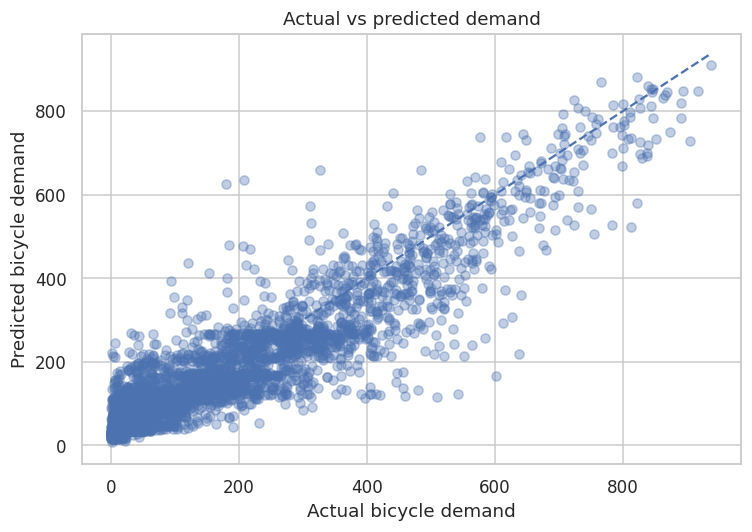

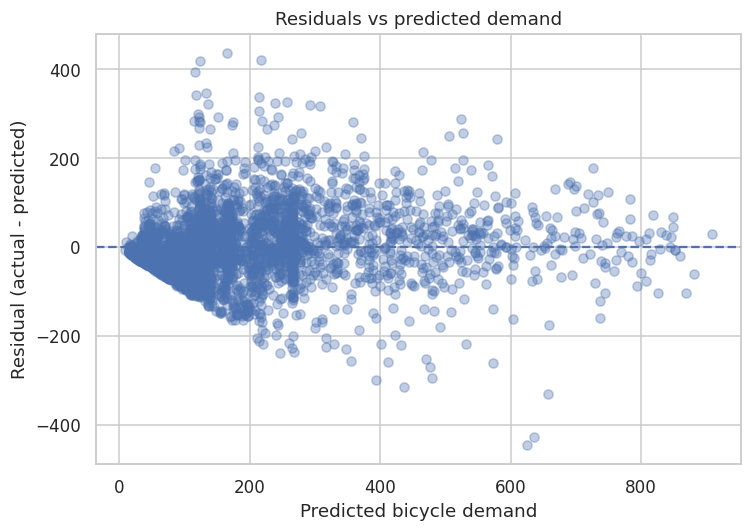


=== DIAGNOSTICS ===
Minimum prediction: 8.35
Maximum prediction: 909.18
Negative predictions: 0
       hr  workingday  weathersit  actual  predicted  residual  abs_error
15019   0           0           1     180   625.4700 -445.4700   445.4700
5537   15           1           1     601   164.8100  436.1900   436.1900
16464  18           1           2     208   635.4800 -427.4800   427.4800
10810  13           0           1     638   217.4600  420.5400   420.5400
16819  14           0           2     542   123.4300  418.5700   418.5700
16650  13           0           2     509   115.2200  393.7800   393.7800
15845  10           0           1     479   132.3000  346.7000   346.7000
6287   13           0           1     460   117.1800  342.8200   342.8200
12890   7           1           1     552   213.4000  338.6000   338.6000
12085  18           1           3     327   658.2500 -331.2500   331.2500
Best candidate by initial CV: RandomForest
Tuned model: RandomForestRegressor
Best RF par

In [53]:
# Target
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y = bikes["cnt"].copy()

X = bikes.drop(columns=["cnt","casual","registered","instant","dteday"])

categorical_features = ["season", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]

numeric_features = ["yr","temp","atemp","hum","windspeed"]

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)
print("Predictor shape:", X.shape)

X_dev, X_test, y_dev, y_test = train_test_split( X, y, test_size=0.20, random_state=SEED)

print("Development rows:", len(X_dev))
print("Test rows:", len(X_test))

preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numeric_features),("cat",
            OneHotEncoder(handle_unknown="ignore"),categorical_features)])

cv = KFold( n_splits=3,shuffle=True,random_state=SEED)

baseline = DummyRegressor(strategy="mean")

baseline_scores = cross_validate(baseline, X_dev, y_dev, cv=cv, scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"})

baseline_rmse = -baseline_scores["test_rmse"]
baseline_r2 = baseline_scores["test_r2"]

print("CV RMSE:", round(baseline_rmse.mean(), 4), "+/-", round(baseline_rmse.std(), 4))

print("CV R2:", round(baseline_r2.mean(), 4), "+/-", round(baseline_r2.std(), 4))

linear_model = Pipeline([("prep", preprocessor), ("model", LinearRegression())])

ridge_model = Pipeline([("prep", preprocessor),("model", Ridge(alpha=1.0))])

rf_model = Pipeline([("prep", preprocessor),("model", RandomForestRegressor( n_estimators=30,max_depth=10,min_samples_leaf=2,
        random_state=SEED, n_jobs=-1))])

models = {"LinearRegression": linear_model,"Ridge": ridge_model, "RandomForest": rf_model}

model_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_dev,
        y_dev,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1
    )

    rmse = -scores["test_rmse"]
    r2 = scores["test_r2"]

    model_results.append({
        "model": name,
        "RMSE_mean": rmse.mean(),
        "RMSE_std": rmse.std(),
        "R2_mean": r2.mean(),
        "R2_std": r2.std()
    })


results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    "RMSE_mean"
)

print(results_df.round(4).to_string(index=False))

rf_for_tuning = Pipeline([("prep", preprocessor),
    ("model", RandomForestRegressor(
        random_state=SEED,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [20, 40],
    "model__max_depth": [8, 12]
}

grid = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    refit=True
)

print("Parameter combinations: 4")
print("CV folds: 3")
print("Total CV fits: 12")

grid.fit(X_dev, y_dev)

print("Best parameters:",  grid.best_params_)
print("Best CV RMSE:",round(-grid.best_score_, 4))


best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test,y_pred))

test_mae = mean_absolute_error(y_test, y_pred)

test_r2 = r2_score(y_test, y_pred)

print("\n RESULTS" )

print("RMSE:", round(test_rmse, 4))

print("MAE:", round(test_mae, 4))

print("R2:", round(test_r2, 4))

print("CV RMSE:",  round(-grid.best_score_, 4))

print( "Test minus CV RMSE:", round(test_rmse - (-grid.best_score_), 4)
)

residuals = (y_test.to_numpy() - y_pred)

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.35)

minimum = min(y_test.min(), y_pred.min())

maximum = max(y_test.max(), y_pred.max())

plt.plot([minimum, maximum], [minimum, maximum],  linestyle="--")

plt.xlabel( "Actual bicycle demand")

plt.ylabel( "Predicted bicycle demand")

plt.title("Actual vs predicted demand")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))

plt.scatter( y_pred, residuals,alpha=0.35)

plt.axhline( 0,linestyle="--")

plt.xlabel("Predicted bicycle demand")

plt.ylabel("Residual (actual - predicted)")

plt.title("Residuals vs predicted demand")

plt.tight_layout()
plt.show()

print("\n=== DIAGNOSTICS ===")

print("Minimum prediction:", round(y_pred.min(), 2))

print("Maximum prediction:", round(y_pred.max(), 2))

print("Negative predictions:", int(np.sum(y_pred < 0)))


diagnostic = X_test.copy()

diagnostic["actual"] = y_test
diagnostic["predicted"] = y_pred
diagnostic["residual"] = residuals
diagnostic["abs_error"] = np.abs(residuals)

print(diagnostic.sort_values("abs_error", ascending=False)
    .head(10)[["hr", "workingday","weathersit","actual","predicted", "residual","abs_error"]]
    .round(2).to_string())

best_cv_model = (results_df.iloc[0]["model"])

print("Best candidate by initial CV:",  best_cv_model)

print("Tuned model:", "RandomForestRegressor")

print("Best RF parameters:", grid.best_params_)

print("Final test RMSE:", round(test_rmse, 4))

print("Final test MAE:", round(test_mae, 4))

print("Final test R2:", round(test_r2, 4))


**Your write-up:**

1. Feature preparation

У датасеті цільовою змінною є cnt — загальна кількість оренд велосипедів за годину. Колонки casual та registered були виключені, тому що їхня сума точно дорівнює cnt. Якщо залишити їх як predictors, модель фактично отримуватиме правильну відповідь наперед, що створює data leakage і робить оцінку моделі неправильною.

Категоріальні ознаки season, mnth, hr, holiday, weekday, workingday та weathersit були закодовані за допомогою one-hot encoding, оскільки їхні числові значення є кодами категорій, а не справжніми числовими величинами. Наприклад, година 20 не є «більшою» за годину 10 у тому сенсі, який потрібен звичайній лінійній моделі. Числові ознаки yr, temp, atemp, hum та windspeed залишилися числовими. Після підготовки отримано 17 379 рядків і 12 початкових predictor-змінних.

2. Split once

Дані були поділені один раз: 80% для development set і 20% для test set. Development set містить 13 903 рядки, а test set — 3 476 рядків. Я використав test_size=0.20, щоб залишити достатньо даних для навчання моделей і водночас мати окрему тестову вибірку для фінальної перевірки. Test set не використовувався під час вибору моделі або налаштування параметрів і був відкритий тільки на кроці 6.

3. Baseline

Як baseline я використовував прогноз середнього значення cnt для кожної години. На cross-validation baseline отримав RMSE = 180.7637 ± 0.0702 та R² = -0.0001 ± 0.0001. Це дуже простий прогноз, тому його результат є точкою відліку для всіх наступних моделей. Хороша модель повинна мати значно менший RMSE і більший R².

4. Comparison of models

На development set я порівняв три моделі за допомогою cross-validation: Random Forest, Ridge Regression та Linear Regression. Random Forest показав RMSE = 86.8284 ± 0.7321 та R² = 0.7692 ± 0.0037. Ridge Regression отримав RMSE = 102.0017 ± 1.3991 та R² = 0.6815 ± 0.0085, а Linear Regression — RMSE = 102.0029 ± 1.3959 та R² = 0.6815 ± 0.0084.

Отже, Random Forest значно покращив результат порівняно з baseline: його RMSE приблизно вдвічі менший, а R² став близьким до 0.77 замість приблизно 0. Це показує, що нелінійна модель краще описує залежність попиту на велосипеди від часу, погоди та інших ознак.

5. Tuning the best model

Найкращим кандидатом за початковою cross-validation була модель Random Forest, тому саме її я налаштовував за допомогою GridSearchCV.

Перевірялися такі параметри:

n_estimators = [20, 40]

max_depth = [8, 12]

Таким чином було 4 комбінації параметрів. Використовувалося 3 CV folds, тому загалом було виконано 12 fits.

Найкращою комбінацією виявилася:

n_estimators = 40

max_depth = 12

Після налаштування CV RMSE покращився до 78.2031.

6. Final test evaluation

Після вибору та налаштування моделі я один раз використав відкладений test set. Фінальний Random Forest отримав RMSE = 76.7385, MAE = 55.3295 та R² = 0.8257.

Cross-validation RMSE для налаштованої моделі становив 78.2031, а test RMSE — 76.7385. Різниця становить -1.4646, тобто test RMSE приблизно на 1.46 велосипеда менший за CV RMSE. Ця різниця невелика, тому результати cross-validation і тестування є досить близькими. Це означає, що модель показала на test set приблизно такий самий рівень помилки, як і очікувалося за cross-validation.

Важливо, що test set був використаний тільки на цьому етапі, тому фінальна оцінка не впливала на вибір моделі.

7. Diagnostics

Мінімальне прогнозоване значення становить 8.35, а максимальне — 909.18. Від'ємних прогнозів немає, тому модель не прогнозує фізично неможливу від'ємну кількість велосипедів.

Графік predicted vs actual показує, наскільки близько прогнозовані значення знаходяться до реальних. Водночас у residuals видно досить великі помилки для деяких годин. Наприклад, для hr=0 модель прогнозувала приблизно 625 велосипедів замість 180, а для hr=15 — приблизно 165 замість 601.

Також видно, що помилки особливо великі для окремих годин із високим або незвичайним попитом. Це означає, що модель добре описує загальну закономірність, але деякі конкретні години вона передбачає значно гірше. Якщо на residual plot залишки розширюються при більших predicted values, це означає, що помилка збільшується для годин із більшим попитом.

8. Final decision

Я б обрав для використання налаштований Random Forest, оскільки він показав найкращий результат на development set і після цього добре підтвердив його на окремому test set. На тестових даних RMSE становить приблизно 76.7 велосипеда, а MAE — приблизно 55.3 велосипеда, тобто в середньому абсолютна помилка прогнозу становить близько 55 велосипедів, хоча великі помилки підвищують RMSE. R² = 0.8257 означає, що модель пояснює близько 82.6% варіації попиту в тестових даних. Найбільш корисним наступним покращенням я б вважав додавання більш інформативних часових ознак, особливо ознак, які краще описують сезонність і типові закономірності попиту протягом дня, оскільки саме для окремих годин модель зараз робить найбільші помилки.

## 12. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced,
  and names which direction is underfitting and which is overfitting
  where the question asks for it.
- Task 10 has a written decision, not only code.